# Model evaluation

In [ ]:
import numpy as np
import pandas as pd 
import xgboost as xgb
from collections import Counter
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss                  
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf                                                                 
from sklearn.model_selection import train_test_split         
from joblib import load                                                           
import sys
sys.path.insert(1, "../../../../module")
from nowcasting_plot import plot_roc, reliability_curve

In [51]:
train = pd.read_csv("../../../../output/data/dakar/data-train-eps-dakar.csv")
test = pd.read_csv("../../../../output/data/dakar/data-test-eps-dakar.csv")
train, validation = train_test_split(train, test_size=0.2, random_state=12)

In [52]:
def choose_header(n, location, lead_time):
    """
    Generate header names for n closest storms.

    Returns:
        tuple of two lists:
            - input headers: year, month, day, hour, minute, lat1..n, lon1..n, wp1..n, size1..n, d1..n, mask1..n
            - target header: Cb_{location}_t{lead_time}
    """
    input_headers = ['year', 'month', 'day', 'hour', 'minute']
    
    for prefix in ['lat', 'lon', 'wp', 'size', 'd', 'mask']:
        input_headers.extend([f'{prefix}{i}' for i in range(1, n + 1)])
    
    target_header = [f'Cb_{location}_t{lead_time}']
    
    return input_headers, target_header

In [53]:
input_headers = ['year', 'month', 'day', 'hour', 'minute']    
for prefix in ['lat', 'lon', 'wp', 'size', 'd', 'mask']:
    input_headers.extend([f'{prefix}{i}' for i in range(1, 4)])

In [54]:
X_train = train[input_headers]
X_val = validation[input_headers]
X_test = test[input_headers]

# t0
y_persistence = test["Cb_dakar_t0"].values.ravel()

# t1
y_train_t1 = train['Cb_dakar_t1'].values.ravel()
y_val_t1 = validation['Cb_dakar_t1'].values.ravel()
y_test_t1 = test['Cb_dakar_t1'].values.ravel()

# t3
y_train_t3 = train['Cb_dakar_t3'].values.ravel()
y_val_t3 = validation['Cb_dakar_t3'].values.ravel()
y_test_t3 = test['Cb_dakar_t3'].values.ravel()

# t6
y_train_t6 = train['Cb_dakar_t6'].values.ravel()
y_val_t6 = validation['Cb_dakar_t6'].values.ravel()
y_test_t6 = test['Cb_dakar_t6'].values.ravel()

In [55]:
for col in ['size1', 'size2', 'size3', 'wp1', 'wp2', 'wp3', 'd1', 'd2', 'd3']:
    X_train.loc[:, col] = np.log1p(X_train[col])
    X_val.loc[:, col] = np.log1p(X_val[col])
    X_test.loc[:, col] = np.log1p(X_test[col])

In [56]:
# Exclude mask columns from scaling
mask_cols = ['mask1', 'mask2', 'mask3']

# Final list of features to scale
cols_to_scale = [col for col in X_train.columns 
                 if col not in mask_cols]

scaler = load('../../lead-time-t1/model-dakar-t1.pkl')

X_train_scaled = X_train.copy()
X_train_scaled[cols_to_scale] = scaler.transform(X_train[cols_to_scale])

X_val_scaled = X_val.copy()
X_val_scaled[cols_to_scale] = scaler.transform(X_val[cols_to_scale])

X_test_scaled = X_test.copy()
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# Loading models

In [57]:
model_t1 = tf.keras.models.load_model('../../lead-time-t1/model-dakar-t1.keras')
model_t3 = tf.keras.models.load_model('../../lead-time-t3/model-dakar-t3.keras')
model_t6 = tf.keras.models.load_model('../../lead-time-t6/model-dakar-t6.keras')

# Inference

In [64]:
# t1 predictions
y_test_pred_t1 = model_t1.predict(X_test_scaled).flatten()
y_train_pred_t1 = model_t1.predict(X_train_scaled).flatten()
y_val_pred_t1 = model_t1.predict(X_val_scaled).flatten()

# t3 predictions
y_test_pred_t3 = model_t3.predict(X_test_scaled).flatten()
y_train_pred_t3 = model_t3.predict(X_train_scaled).flatten()
y_val_pred_t3 = model_t3.predict(X_val_scaled).flatten()

# t6 predictions
y_test_pred_t6 = model_t6.predict(X_test_scaled).flatten()
y_train_pred_t6 = model_t6.predict(X_train_scaled).flatten()
y_val_pred_t6 = model_t6.predict(X_val_scaled).flatten()


695/695 ━━━━━━━━━━━━━━━━━━━━ 1s 855us/step
2805/2805 ━━━━━━━━━━━━━━━━━━━━ 3s 893us/step
702/702 ━━━━━━━━━━━━━━━━━━━━ 1s 904us/step
695/695 ━━━━━━━━━━━━━━━━━━━━ 1s 965us/step
2805/2805 ━━━━━━━━━━━━━━━━━━━━ 2s 763us/step
702/702 ━━━━━━━━━━━━━━━━━━━━ 1s 855us/step
695/695 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
2805/2805 ━━━━━━━━━━━━━━━━━━━━ 2s 760us/step
702/702 ━━━━━━━━━━━━━━━━━━━━ 1s 750us/step


In [59]:
from sklearn.metrics import roc_auc_score

# --- AUC for t1 ---
auc_train_t1 = roc_auc_score(y_train_t1, y_train_pred_t1)
auc_val_t1   = roc_auc_score(y_val_t1, y_val_pred_t1)
auc_test_t1  = roc_auc_score(y_test_t1, y_test_pred_t1)

# --- AUC for t3 ---
auc_train_t3 = roc_auc_score(y_train_t3, y_train_pred_t3)
auc_val_t3   = roc_auc_score(y_val_t3, y_val_pred_t3)
auc_test_t3  = roc_auc_score(y_test_t3, y_test_pred_t3)

# --- AUC for t6 ---
auc_train_t6 = roc_auc_score(y_train_t6, y_train_pred_t6)
auc_val_t6   = roc_auc_score(y_val_t6, y_val_pred_t6)
auc_test_t6  = roc_auc_score(y_test_t6, y_test_pred_t6)

# Persistence AUCs
auc_persistence_t1 = roc_auc_score(y_test_t1, y_persistence)
auc_persistence_t3 = roc_auc_score(y_test_t3, y_persistence)
auc_persistence_t6 = roc_auc_score(y_test_t6, y_persistence)

# Training and testing ROCs

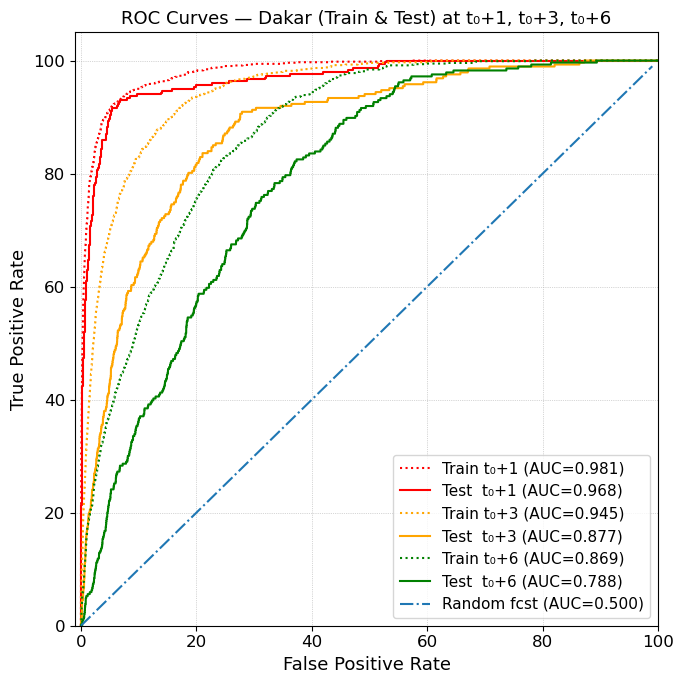

In [60]:
plt.figure(figsize=(7, 7))

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
})


# --- t+1 ---
plot_roc(f"Train t₀+1 (AUC={auc_train_t1:.3f})", y_train_t1, y_train_pred_t1, color="red", linestyle=':')
plot_roc(f"Test  t₀+1 (AUC={auc_test_t1:.3f})",  y_test_t1,  y_test_pred_t1,  color="red", linestyle='-')

# --- t+3 ---
plot_roc(f"Train t₀+3 (AUC={auc_train_t3:.3f})", y_train_t3, y_train_pred_t3, color="orange", linestyle=':')
plot_roc(f"Test  t₀+3 (AUC={auc_test_t3:.3f})",  y_test_t3,  y_test_pred_t3,  color="orange", linestyle='-')

# --- t+6 ---
plot_roc(f"Train t₀+6 (AUC={auc_train_t6:.3f})", y_train_t6, y_train_pred_t6, color="green", linestyle=':')
plot_roc(f"Test  t₀+6 (AUC={auc_test_t6:.3f})",  y_test_t6,  y_test_pred_t6,  color="green", linestyle='-')

# Random line
plt.plot(range(0,100), range(0,100), label='Random fcst (AUC=0.500)', linestyle='-.', linewidth=1.5)

plt.title("ROC Curves — Dakar (Train & Test) at t₀+1, t₀+3, t₀+6", fontsize=13)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


# Test and Persistence ROCs

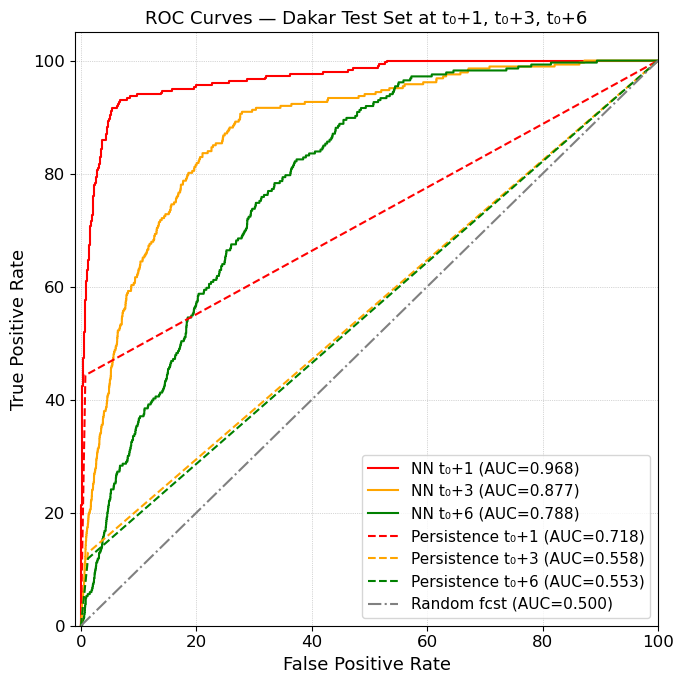

In [71]:
plt.figure(figsize=(7, 7))

# --- NN model predictions (Test)
plot_roc(f"NN t₀+1 (AUC={auc_test_t1:.3f})", y_test_t1, y_test_pred_t1, color="red", linestyle='-')
plot_roc(f"NN t₀+3 (AUC={auc_test_t3:.3f})", y_test_t3, y_test_pred_t3, color="orange", linestyle='-')
plot_roc(f"NN t₀+6 (AUC={auc_test_t6:.3f})", y_test_t6, y_test_pred_t6, color="green", linestyle='-')

# --- Persistence baselines (t₀ → t₀+X)
plot_roc(f"Persistence t₀+1 (AUC={auc_persistence_t1:.3f})", y_test_t1, y_persistence, color="red", linestyle='--')
plot_roc(f"Persistence t₀+3 (AUC={auc_persistence_t3:.3f})", y_test_t3, y_persistence, color="orange", linestyle='--')
plot_roc(f"Persistence t₀+6 (AUC={auc_persistence_t6:.3f})", y_test_t6, y_persistence, color="green", linestyle='--')

# Random forecast line
plt.plot([0, 100], [0, 100], label='Random fcst (AUC=0.500)', linestyle='-.', linewidth=1.5, color='gray')

plt.title("ROC Curves — Dakar Test Set at t₀+1, t₀+3, t₀+6", fontsize=13)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


# Reliability diagrams

In [83]:
# t₀+1
prob_pred_t1, prob_true_t1, count_t1 = reliability_curve(y_test_t1, y_test_pred_t1, min_predictions_per_bin=50)
count_t1 = [i / (1.1 * np.max(count_t1)) for i in count_t1]

# t₀+3
prob_pred_t3, prob_true_t3, count_t3 = reliability_curve(y_test_t3, y_test_pred_t3, min_predictions_per_bin=10)
count_t3 = [i / (1.1 * np.max(count_t3)) for i in count_t3]

# t₀+6
prob_pred_t6, prob_true_t6, count_t6 = reliability_curve(y_test_t6, y_test_pred_t6, min_predictions_per_bin=10)
count_t6 = [i / (1.1 * np.max(count_t6)) for i in count_t6]


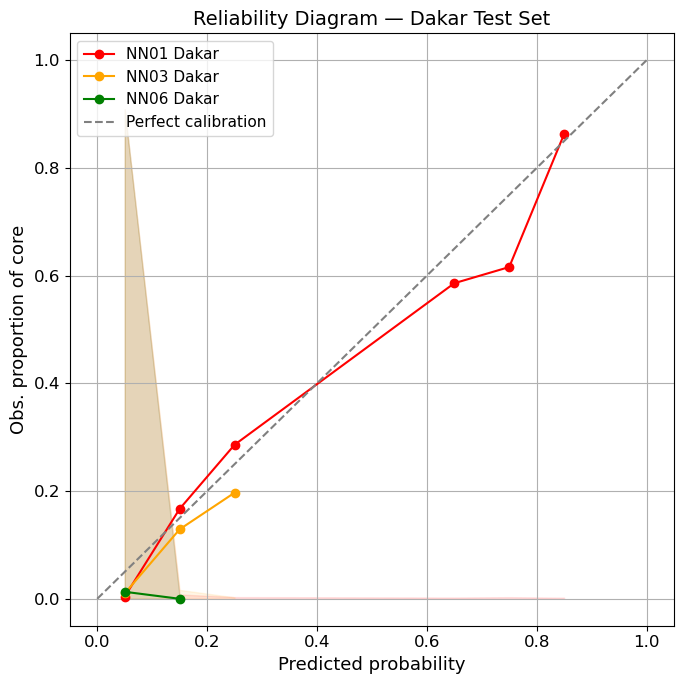

In [84]:
plt.figure(figsize=(7, 7))

# Reliability curves
plt.plot(prob_pred_t1, prob_true_t1, marker='o', label="NN01 Dakar", color='red')
plt.plot(prob_pred_t3, prob_true_t3, marker='o', label="NN03 Dakar", color='orange')
plt.plot(prob_pred_t6, prob_true_t6, marker='o', label="NN06 Dakar", color='green')

# Reference line
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')

# Normalized counts (light bars)
plt.fill_between(prob_pred_t1, 0, count_t1, color='red', alpha=0.1)
plt.fill_between(prob_pred_t3, 0, count_t3, color='orange', alpha=0.1)
plt.fill_between(prob_pred_t6, 0, count_t6, color='green', alpha=0.1)

plt.xlabel("Predicted probability")
plt.ylabel("Obs. proportion of core")
plt.title("Reliability Diagram — Dakar Test Set")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
